# 少量示例的提示词模板的使用

FewShotPromptTemplate: 与PromptTemplate一起使用

FewShotChatMessagePromptTemplate:与ChatPromptTemplate一起使用

Example selectors(示例选择器):

## 1、FewShotPromptTemplate的使用


举例1：未提供示例的情况

In [ ]:

import os
import dotenv
from langchain_core.prompts import FewShotPromptTemplate
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
# 创建模型实例
chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b",
                        temperature=0.4)
#   创建FewShotPromptTemplate的实例
res = chat_model.invoke("2 🦜 9是多少?")
print(res.content)

2 妖虫，9 是指 9 蚂虫。


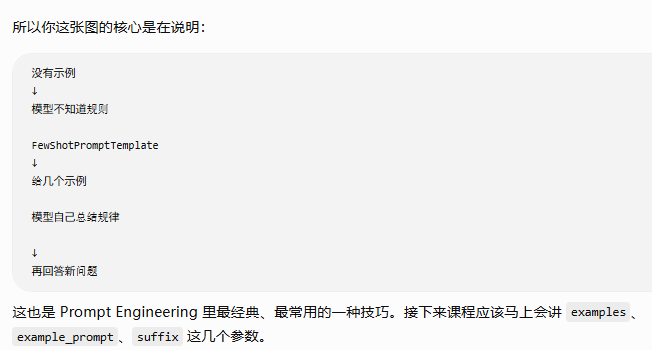

举例2：使用FewShotPromptTemplate



In [3]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate

example_prompt = PromptTemplate.from_template(
    "input:{input}\noutput:{output}"
)

examples = [
    {"input":"北京天气怎么样","output":"北京市"},
    {"input":"南京下雨吗","output":"南京市"},
    {"input":"武汉热吗","output":"武汉市"}
]

few_shot_template = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="input:{input}\noutput:",
    input_variables=["input"]
)

prompt = few_shot_template.format(
    input="天津会下雨吗？"
)

print(prompt)

input:北京天气怎么样
output:北京市
input:南京下雨吗
output:南京市
input:武汉热吗
output:武汉市
input:天津会下雨吗？
output:


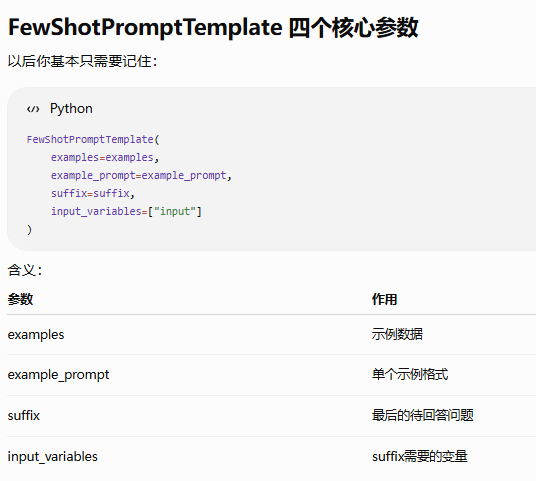

调用大模型以后：

In [5]:
import os
import dotenv
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b")

In [6]:
chat_model.invoke(few_shot_template.invoke({"input":"天津会下雨吗？"}))

AIMessage(content='南京市', additional_kwargs={})

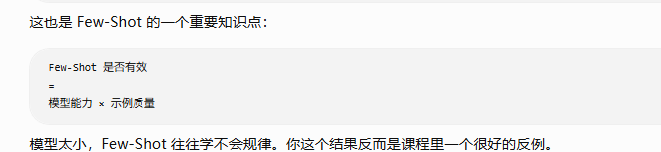

举例3：


In [1]:
import os
import dotenv

from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from langchain_openai import ChatOpenAI

# 1. 示例格式
example_prompt = PromptTemplate.from_template(
    "算式：{input}\n结果：{output}\n说明：{description}"
)

# 2. 示例数据
examples = [
    {
        "input": "2+2",
        "output": "4",
        "description": "加法运算"
    },
    {
        "input": "5-2",
        "output": "3",
        "description": "减法运算"
    }
]

# 3. FewShotPromptTemplate
prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    prefix="你是一个数学专家。请根据下面示例回答最后一个算式的结果。",
    suffix="算式：{input}\n结果：",
    input_variables=["input"]
)

# 4. 生成最终 Prompt
final_prompt = prompt.format(
    input="2*5"
)

print("===== 最终 Prompt =====")
print(final_prompt)

# 5. 调用模型
dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

chat_model = ChatOpenAI(
    model=os.getenv("OLLAMA_MODEL")
)

result = chat_model.invoke(final_prompt)

print("\n===== AI回答 =====")
print(result.content)

===== 最终 Prompt =====
你是一个数学专家。请根据下面示例回答最后一个算式的结果。
算式：2+2
结果：4
说明：加法运算
算式：5-2
结果：3
说明：减法运算
算式：2*5
结果：

===== AI回答 =====
算式：2*5
结果：10


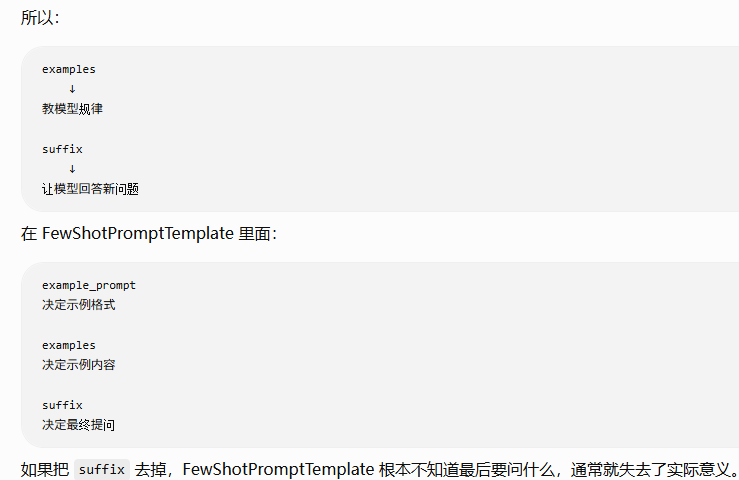

# 2、FewShotChatMessagePromptTemplate的使用

举例1：实例化

In [3]:
from langchain.prompts import (
    FewShotChatMessagePromptTemplate,
    ChatPromptTemplate
)

# 1.示例消息格式
examples = [
    {"input": "1+1等于几？", "output": "1+1等于2"},
    {"input": "法国的首都是？", "output": "巴黎"}
]

# 2.定义示例的消息格式提示词模版
msg_example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{input}"),
    ("ai", "{output}"),
])

# 3.定义FewShotChatMessagePromptTemplate对象
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=msg_example_prompt,
    examples=examples
)
# 4.输出格式化后的消息
#print(few_shot_prompt.format())
messages = few_shot_prompt.format_messages()

print(messages)

[HumanMessage(content='1+1等于几？', additional_kwargs={}), AIMessage(content='1+1等于2', additional_kwargs={}), HumanMessage(content='法国的首都是？', additional_kwargs={}), AIMessage(content='巴黎', additional_kwargs={})]


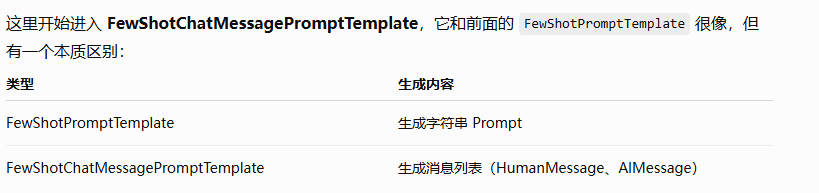

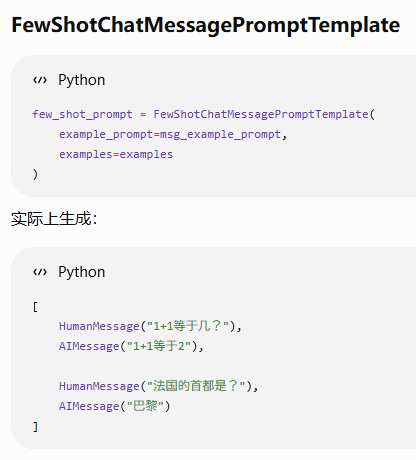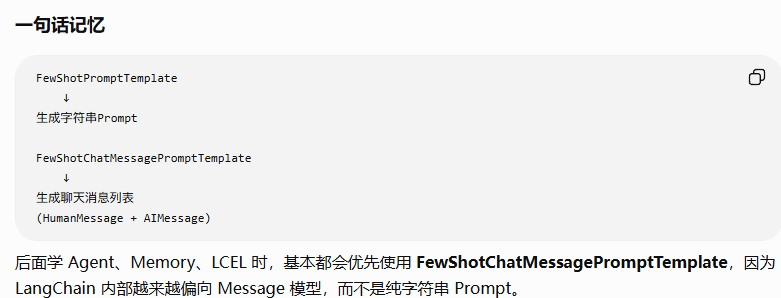

举例2：

In [5]:
# 1.导入相关包
from langchain_core.prompts import (FewShotChatMessagePromptTemplate, ChatPromptTemplate)

# 2.定义示例组
examples = [
    {"input": "2🦜2", "output": "4"},
    {"input": "2🦜3", "output": "6"},
]

# 3.定义示例的消息格式提示词模版
example_prompt = ChatPromptTemplate.from_messages([
    ('human', '{input} 是多少?'),
    ('ai', '{output}')
])

# 4.定义FewShotChatMessagePromptTemplate对象
few_shot_prompt = FewShotChatMessagePromptTemplate(
    examples=examples,  # 示例组
    example_prompt=example_prompt,  # 示例提示词词模版
)
# 5.输出完整提示词的消息模版
final_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', '你是一个数学奇才'),
        few_shot_prompt,
        ('human', '{input}'),
    ]
)

#6.提供大模型
import os
import dotenv
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

chat_model = ChatOpenAI(model="qwen2.5-coder:1.5b",
                        temperature=0.4)

# 7. 先生成最终 PromptValue
prompt_value = final_prompt.invoke({
    "input": "2 🐛 4"
})

print("===== 1. 最终 PromptValue 类型 =====")
print(type(prompt_value))

print("\n===== 2. 最终消息列表 =====")
for i, msg in enumerate(prompt_value.messages, start=1):
    print(f"\n--- 第 {i} 条消息 ---")
    print("类型：", type(msg).__name__)
    print("内容：", msg.content)

print("\n===== 3. 转成字符串查看 =====")
print(prompt_value.to_string())

# 8. 调用模型
response = chat_model.invoke(prompt_value)

print("\n===== 4. AIMessage对象 =====")
print(response)

print("\n===== 5. AI最终回答 =====")
print(response.content)

===== 1. 最终 PromptValue 类型 =====
<class 'langchain_core.ChatPromptValue'>

===== 2. 最终消息列表 =====

--- 第 1 条消息 ---
类型： SystemMessage
内容： 你是一个数学奇才

--- 第 2 条消息 ---
类型： HumanMessage
内容： 2🦜2 是多少?

--- 第 3 条消息 ---
类型： AIMessage
内容： 4

--- 第 4 条消息 ---
类型： HumanMessage
内容： 2🦜3 是多少?

--- 第 5 条消息 ---
类型： AIMessage
内容： 6

--- 第 6 条消息 ---
类型： HumanMessage
内容： 2 🐛 4

===== 3. 转成字符串查看 =====
你是一个数学奇才
2🦜2 是多少?
4
2🦜3 是多少?
6
2 🐛 4

===== 4. AIMessage对象 =====
AIMessage(content='8', additional_kwargs={})

===== 5. AI最终回答 =====
8


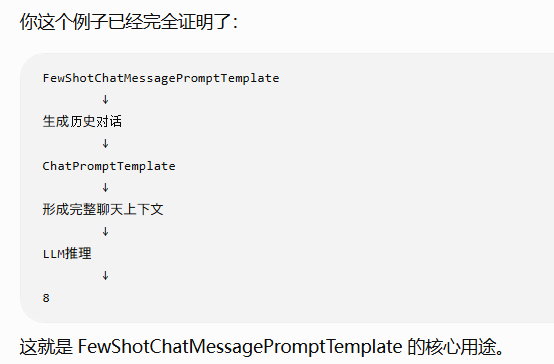

## 3、Example selectors(示例选择器)

举例1：动态 Few-Shot（语义相似度示例选择）

In [8]:
# 1.导入相关包
from langchain_community.vectorstores import Chroma
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
import os
import dotenv
from langchain_ollama import OllamaEmbeddings

dotenv.load_dotenv()

# 2.定义嵌入模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

embeddings_model = OllamaEmbeddings(
    model="nomic-embed-text"
)

# 3.定义示例组
examples = [
    {
        "question": "谁活得更久，穆罕默德·阿里还是艾伦·图灵?",
        "answer": """
        接下来还需要问什么问题吗？
        追问：穆罕默德·阿里去世时多大年纪？
        中间答案：穆罕默德·阿里去世时享年74岁。
        """,
    },
    {
        "question": "craigslist的创始人是什么时候出生的？",
        "answer": """
        接下来还需要问什么问题吗？
        追问：谁是craigslist的创始人？
        中级答案：Craigslist是由克雷格·纽马克创立的。
        """,
    },
    {
        "question": "谁是乔治·华盛顿的外祖父？",
        "answer": """
        接下来还需要问什么问题吗？
        追问：谁是乔治·华盛顿的母亲？
        中间答案：乔治·华盛顿的母亲是玛丽·鲍尔·华盛顿。
        """,
    },
    {
        "question": "《大白鲨》和《皇家赌场》的导演都来自同一个国家吗？",
        "answer": """
        接下来还需要问什么问题吗？
        追问：《大白鲨》的导演是谁？
        中级答案：《大白鲨》的导演是史蒂文·斯皮尔伯格。
        """,
    },
]

# 4.定义示例选择器
example_selector = SemanticSimilarityExampleSelector.from_examples(
    # 这是可供选择的示例列表
    examples,
    # 这是用于生成嵌入的嵌入类，用于衡量语义相似性  Embedding模型
    embeddings_model,
    # 这是用于存储嵌入并进行相似性搜索的 VectorStore 类， chroma是向量数据库，见上面所有example全部转换成向量然后存进chroma
    Chroma,
    # 这是要生成的示例数量， 返回最相似的1条
    k=1,
)

# 选择与输入最相似的示例
question = "诸葛亮为什么被称为卧龙？"

print("=" * 50)
print("用户输入")
print("=" * 50)
print(question)

selected_examples = example_selector.select_examples(
    {"question": question}
)

print("\n" + "=" * 50)
print("向量检索结果")
print("=" * 50)

print("\n===== 所有候选问题 =====")
for i, ex in enumerate(examples, 1):
    print(f"{i}. {ex['question']}")
    
for i, ex in enumerate(selected_examples, 1):
    print(f"\n【示例{i}】")
    print(f"Question: {ex['question']}")
    print(f"Answer:\n{ex['answer']}")

# for example in selected_examples:
#     print("\n")
#     for k, v in example.items():
#         print(f"{k}: {v}")

用户输入
诸葛亮为什么被称为卧龙？

向量检索结果

===== 所有候选问题 =====
1. 谁活得更久，穆罕默德·阿里还是艾伦·图灵?
2. craigslist的创始人是什么时候出生的？
3. 谁是乔治·华盛顿的外祖父？
4. 《大白鲨》和《皇家赌场》的导演都来自同一个国家吗？

【示例1】
Question: 谁活得更久，穆罕默德·阿里还是艾伦·图灵?
Answer:

        接下来还需要问什么问题吗？
        追问：穆罕默德·阿里去世时多大年纪？
        中间答案：穆罕默德·阿里去世时享年74岁。
        


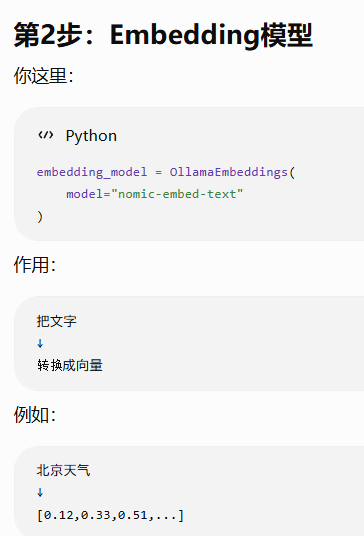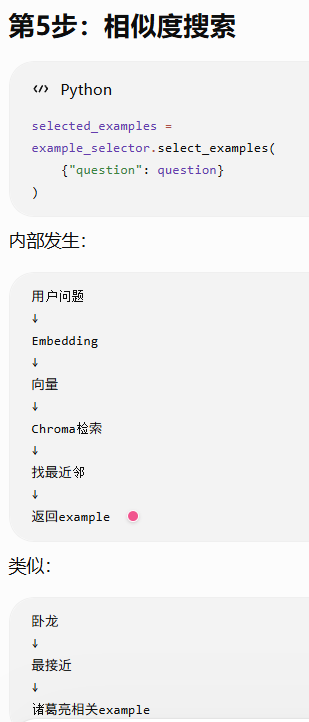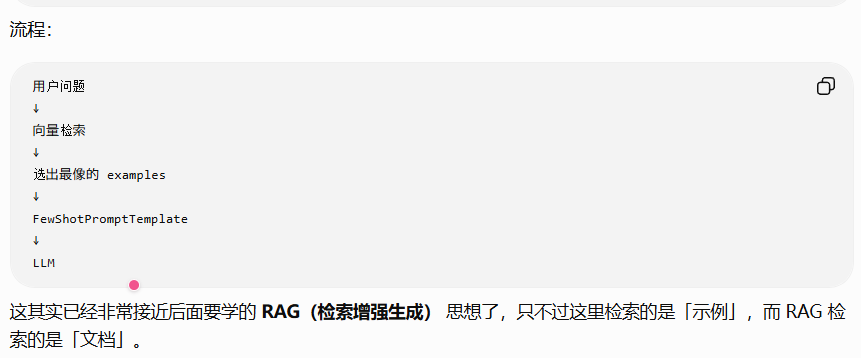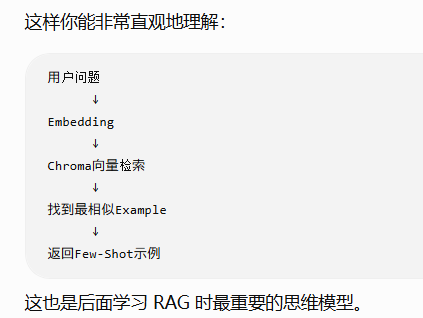

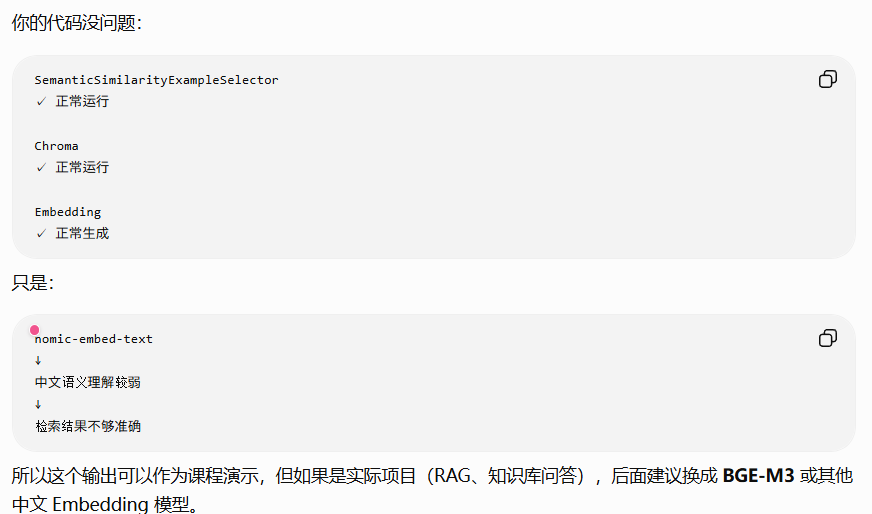

举例2：

In [ ]:
# 1.导入相关包
from langchain_community.vectorstores import FAISS
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate
from langchain_ollama import OllamaEmbeddings

# 2.定义示例提示词模版
example_prompt = PromptTemplate.from_template(
    template="Input: {input}\nOutput: {output}",
)

# 3.创建一个示例提示词模版
examples = [
    {"input": "高兴", "output": "悲伤"},
    {"input": "高", "output": "矮"},
    {"input": "长", "output": "短"},
    {"input": "精力充沛", "output": "无精打采"},
    {"input": "阳光", "output": "阴暗"},
    {"input": "粗糙", "output": "光滑"},
    {"input": "干燥", "output": "潮湿"},
    {"input": "富裕", "output": "贫穷"},
]

# 4.定义嵌入模型
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

# 5.创建语义相似性示例选择器
example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples,
    embeddings,
    FAISS,      #FAISS（读作 "Faiss"）是 Facebook（现在叫 Meta）开发的一个向量检索库（Vector Search Library）
    k=2,
)
#或者
#example_selector = SemanticSimilarityExampleSelector(
#    examples,
#    embeddings,
#    FAISS,
#    k=2
#)

# 6.定义小样本提示词模版
similar_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=example_prompt,
    prefix="给出每个词组的反义词",
    suffix="Input: {word}\nOutput:",
    input_variables=["word"],
)

response = similar_prompt.invoke({"word":"忧郁"})
#print(response.text)
word = "沉郁"

print("=" * 50)
print("用户输入")
print("=" * 50)
print(word)

selected_examples = example_selector.select_examples(
    {"input": word}
)

print("\n" + "=" * 50)
print("向量检索结果")
print("=" * 50)

for i, ex in enumerate(selected_examples, 1):
    print(f"\n【示例{i}】")
    print(f"Input : {ex['input']}")
    print(f"Output: {ex['output']}")

prompt_value = similar_prompt.invoke(
    {"word": word}
)

print("\n" + "=" * 50)
print("最终Prompt")
print("=" * 50)
print(prompt_value.text)

response = chat_model.invoke(
    prompt_value.text
)

print("\n" + "=" * 50)
print("AI回答")
print("=" * 50)
print(response.content)

用户输入
沉郁

向量检索结果

【示例1】
Input : 高兴
Output: 悲伤

【示例2】
Input : 高
Output: 矮

最终Prompt
给出每个词组的反义词
Input: 高兴
Output: 悲伤
Input: 高
Output: 矮
Input: 沉郁
Output:

AI回答
好的，以下是每个词组的反义词：

1. 高兴 (快乐)
2. 高 (矮)
3. 沉郁 (开朗)


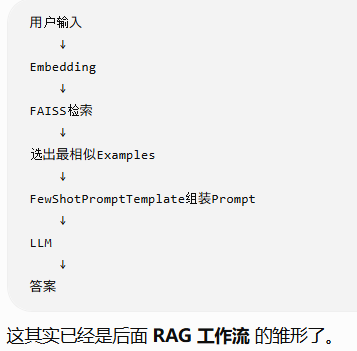